# Compare Results - AWS Spark vs Python (pandas/scikit-learn)

Run this AFTER both spark_pipeline.py and pandas_pipeline.py
have produced their metrics csv files. Generates a summary table and
a bar chart comparing stage-by-stage runtime

Saved: combined_metrics.csv

--- Dataset & Model Summary ---


,Metric,Spark,Python
0,Raw Row Count,"23,992,355","23,992,355"
1,Clean Row Count,"16,803,729","16,803,729"
2,RMSE,13.379,13.457
3,R2,0.458,0.451



--- Stage Timings Comparison ---


,Stage,Spark (s),Python (s),Speedup (Python/Spark)
0,Load Data,17.90,6.68,0.37
1,Cleaning,23.22,70.57,3.04
2,Join Pickup Zone,21.95,3.74,0.17
3,Aggregation Zone Hour,0.05,1.49,29.72
4,Aggregation Day Of Week,0.03,0.88,29.47
5,Aggregation Payment Type,0.07,4.82,68.79
6,Join Dropoff Zone Borough Flow,0.08,4.16,52.01
7,Ml Training,35.66,54.62,1.53
8,Ml Evaluation,13.31,1.19,0.09
9,TOTAL,122.75,148.15,1.21


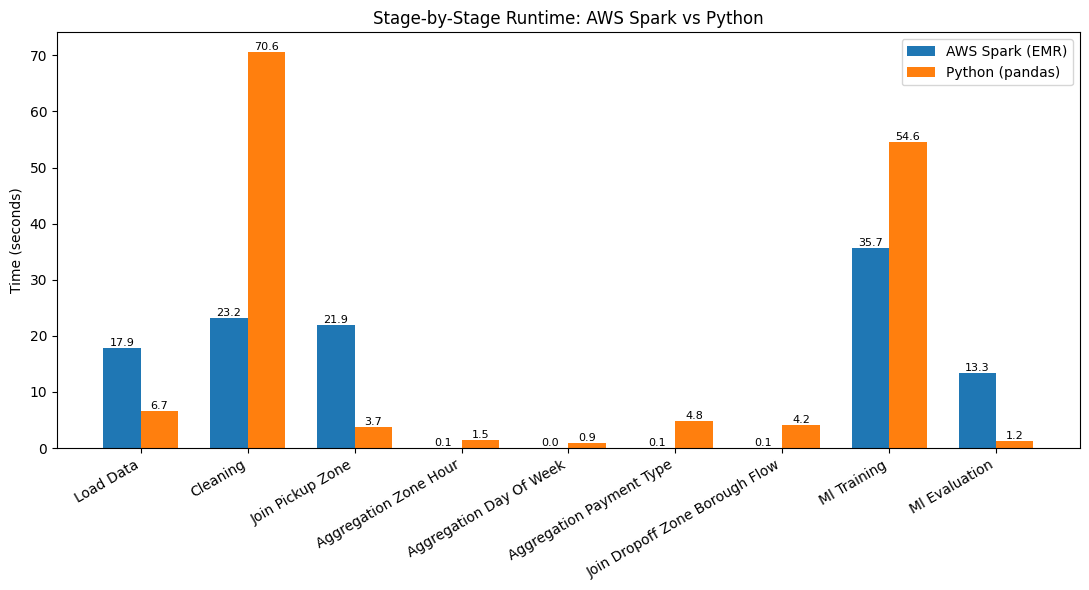

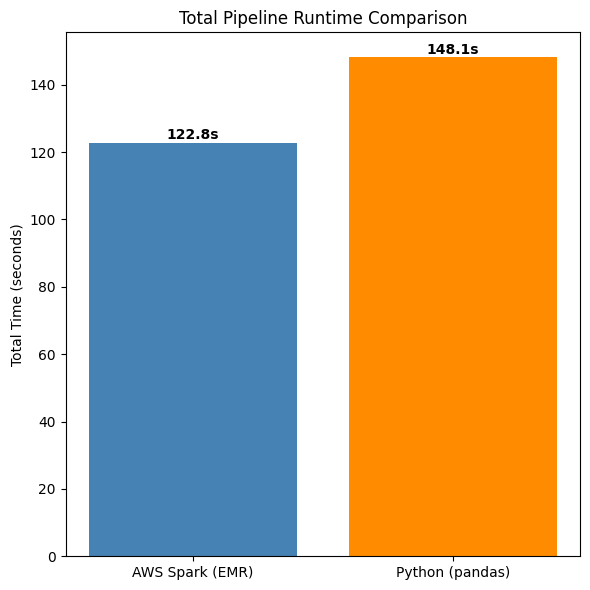


--- Python Peak Memory per Stage ---


,Stage,Peak Memory (MB)
1,Cleaning,2551.54
8,Ml Training,2334.21
0,Load Data,1647.55
2,Join Zones,929.49
6,Join Do Zone,929.49
5,Aggregation Payment Type,817.30
3,Aggregation Zone Hour,689.12
7,Aggregation Borough Flow,544.88
9,Ml Evaluation,459.34
4,Aggregation Day Of Week,256.43


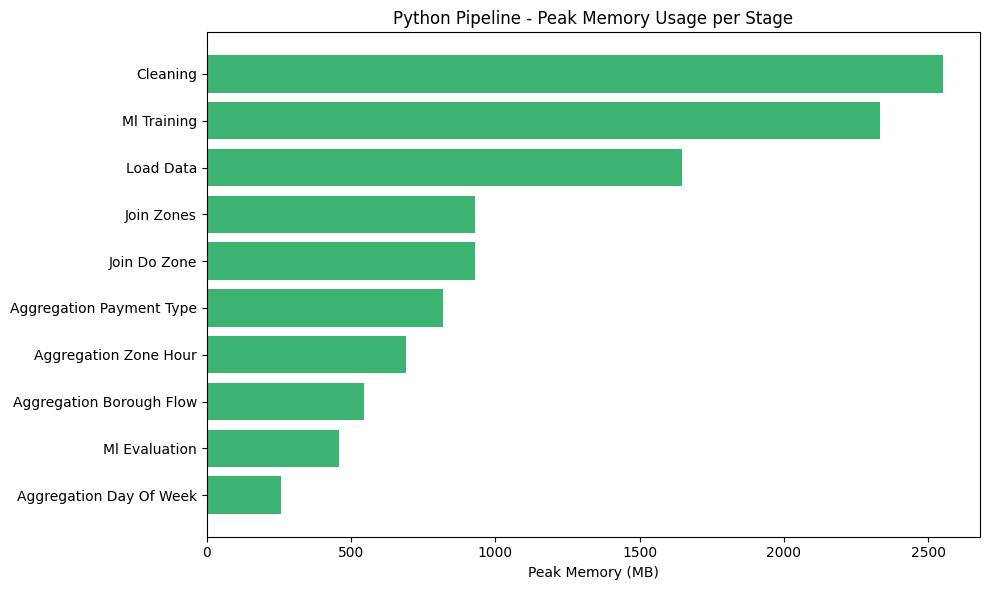

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Load both files (they use different schemas, so parsed separately)
# ---------------------------------------------------------------------
sprk_raw = pd.read_csv("metrics_spark.csv")     # wide format: one row per stage
python_raw = pd.read_csv("metrics_python.csv")   # long format: metric,value

# ---------------------------------------------------------------------
# 2. Parse Spark metrics (wide format)
# ---------------------------------------------------------------------
spark_total_row = sprk_raw[sprk_raw["stage"] == "Total Pipeline"].iloc[0]

spark_summary = {
    "platform": sprk_raw["platform"].iloc[0],
    "raw_row_count": int(spark_total_row["raw_row_count"]),
    "clean_row_count": int(spark_total_row["clean_row_count"]),
    "total_time_sec": float(spark_total_row["execution_time_sec"]),
    "model_rmse": float(spark_total_row["rmse"]),
    "model_r2": float(spark_total_row["r2"]),
}

spark_stage_times = dict(
    zip(sprk_raw["stage"], sprk_raw["execution_time_sec"])
)
spark_stage_times.pop("Total Pipeline")  # keep only actual stages, not the total

# ---------------------------------------------------------------------
# 3. Parse Python metrics (long format)
# ---------------------------------------------------------------------
python_kv = dict(zip(python_raw["metric"], python_raw["value"]))

def to_num(v):
    try:
        v = float(v)
        return int(v) if v.is_integer() else v
    except (ValueError, TypeError):
        return v

python_summary = {
    "platform": python_kv["platform"],
    "raw_row_count": to_num(python_kv["raw_row_count"]),
    "clean_row_count": to_num(python_kv["clean_row_count"]),
    "total_time_sec": to_num(python_kv["total_time_sec"]),
    "model_rmse": to_num(python_kv["model_rmse"]),
    "model_r2": to_num(python_kv["model_r2"]),
}

python_stage_times = {
    k.replace("stage_", "").replace("_time_sec", ""): to_num(v)
    for k, v in python_kv.items()
    if k.startswith("stage_") and k.endswith("_time_sec")
}

python_stage_memory = {
    k.replace("stage_", "").replace("_peak_memory_mb", ""): to_num(v)
    for k, v in python_kv.items()
    if k.startswith("stage_") and k.endswith("_peak_memory_mb")
}

# ---------------------------------------------------------------------
# 4. Map Spark stage names <-> Python stage keys onto one canonical name.
#    Spark's "Join Dropoff Zone + Borough Flow" covers two stages the
#    Python side timed separately, so those two are summed for a fair match.
# ---------------------------------------------------------------------
stage_map = {
    "load_data":                      ("Load Data",                          ["load_data"]),
    "cleaning":                       ("Data Cleaning",                      ["cleaning"]),
    "join_pickup_zone":               ("Join Pickup Zone",                   ["join_zones"]),
    "aggregation_zone_hour":          ("Aggregation Zone Hour",              ["aggregation_zone_hour"]),
    "aggregation_day_of_week":        ("Aggregation Day Of Week",            ["aggregation_day_of_week"]),
    "aggregation_payment_type":       ("Aggregation Payment Type",           ["aggregation_payment_type"]),
    "join_dropoff_zone_borough_flow": ("Join Dropoff Zone + Borough Flow",   ["join_do_zone", "aggregation_borough_flow"]),
    "ml_training":                    ("ML Training",                        ["ml_training"]),
    "ml_evaluation":                  ("ML Prediction Evaluation",           ["ml_evaluation"]),
}

stage_rows = []
for canonical, (spark_key, python_keys) in stage_map.items():
    spark_t = spark_stage_times.get(spark_key)
    python_t = sum(python_stage_times.get(k, 0) for k in python_keys) or None
    speedup = round(python_t / spark_t, 2) if spark_t and python_t else None
    stage_rows.append({
        "Stage": canonical.replace("_", " ").title(),
        "Spark (s)": spark_t,
        "Python (s)": python_t,
        "Speedup (Python/Spark)": speedup,
    })

stage_rows.append({
    "Stage": "TOTAL",
    "Spark (s)": spark_summary["total_time_sec"],
    "Python (s)": python_summary["total_time_sec"],
    "Speedup (Python/Spark)": round(python_summary["total_time_sec"] / spark_summary["total_time_sec"], 2),
})

timings_df = pd.DataFrame(stage_rows)

# ---------------------------------------------------------------------
# 5. Combine everything into ONE clean CSV
# ---------------------------------------------------------------------
combined_rows = []

# Dataset info
combined_rows.append({"Category": "Dataset", "Metric": "Raw Row Count", "Spark": spark_summary["raw_row_count"], "Python": python_summary["raw_row_count"]})
combined_rows.append({"Category": "Dataset", "Metric": "Clean Row Count", "Spark": spark_summary["clean_row_count"], "Python": python_summary["clean_row_count"]})

# Model accuracy
combined_rows.append({"Category": "Model", "Metric": "RMSE", "Spark": spark_summary["model_rmse"], "Python": python_summary["model_rmse"]})
combined_rows.append({"Category": "Model", "Metric": "R2", "Spark": spark_summary["model_r2"], "Python": python_summary["model_r2"]})

# Runtime per stage
for row in stage_rows:
    combined_rows.append({"Category": "Runtime (s)", "Metric": row["Stage"], "Spark": row["Spark (s)"], "Python": row["Python (s)"]})

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv("combined_metrics.csv", index=False)
print("Saved: combined_metrics.csv")

# ---------------------------------------------------------------------
# 6. Display tables
# ---------------------------------------------------------------------
print("\n--- Dataset & Model Summary ---")
summary_df = combined_df[combined_df["Category"].isin(["Dataset", "Model"])].drop(columns="Category").copy()

# Prepare summary_df for display with desired formatting
summary_df_display = summary_df.copy()

# Explicitly convert 'Spark' and 'Python' columns to object (string) dtype to avoid FutureWarning
summary_df_display['Spark'] = summary_df_display['Spark'].astype(object)
summary_df_display['Python'] = summary_df_display['Python'].astype(object)

for col in ['Spark', 'Python']:
    # Raw and Clean Row Count: format as integers with comma separators
    summary_df_display.loc[summary_df_display['Metric'].isin(['Raw Row Count', 'Clean Row Count']), col] = \
        summary_df_display.loc[summary_df_display['Metric'].isin(['Raw Row Count', 'Clean Row Count']), col].apply(lambda x: f"{int(float(x)):,}")
    # RMSE and R2: format as floats with three decimal places
    summary_df_display.loc[summary_df_display['Metric'].isin(['RMSE', 'R2']), col] = \
        summary_df_display.loc[summary_df_display['Metric'].isin(['RMSE', 'R2']), col].apply(lambda x: f"{float(x):.3f}")

display(summary_df_display)

print("\n--- Stage Timings Comparison ---")
display(timings_df.round(2))

# ---------------------------------------------------------------------
# 7. Bar chart - stage-by-stage runtime (excluding TOTAL)
# ---------------------------------------------------------------------
chart_df = timings_df[timings_df["Stage"] != "TOTAL"]

x = range(len(chart_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar([i - width / 2 for i in x], chart_df["Spark (s)"], width, label="AWS Spark (EMR)")
rects2 = ax.bar([i + width / 2 for i in x], chart_df["Python (s)"], width, label="Python (pandas)")
ax.set_ylabel("Time (seconds)")
ax.set_title("Stage-by-Stage Runtime: AWS Spark vs Python")
ax.set_xticks(list(x))
ax.set_xticklabels(chart_df["Stage"], rotation=30, ha="right")
ax.legend()

# Add data labels for Spark bars
for rect in rects1:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=8)

# Add data labels for Python bars
for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 8. Total runtime comparison (single bar pair, easy headline chart)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(["AWS Spark (EMR)", "Python (pandas)"],
       [spark_summary["total_time_sec"], python_summary["total_time_sec"]],
       color=["steelblue", "darkorange"])
ax.set_ylabel("Total Time (seconds)")
ax.set_title("Total Pipeline Runtime Comparison")
for i, v in enumerate([spark_summary["total_time_sec"], python_summary["total_time_sec"]]):
    ax.text(i, v + 1, f"{v:.1f}s", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 9. Python memory usage per stage (Spark side has no equivalent
#    metric, so this is shown as a standalone chart, not a comparison)
# ---------------------------------------------------------------------
mem_df = pd.DataFrame(
    [{"Stage": k.replace("_", " ").title(), "Peak Memory (MB)": v} for k, v in python_stage_memory.items()]
).sort_values("Peak Memory (MB)", ascending=False)

print("\n--- Python Peak Memory per Stage ---")
display(mem_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mem_df["Stage"], mem_df["Peak Memory (MB)"], color="mediumseagreen")
ax.set_xlabel("Peak Memory (MB)")
ax.set_title("Python Pipeline - Peak Memory Usage per Stage")
ax.invert_yaxis()
plt.tight_layout()
plt.show()